In [136]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from scipy import stats
from sklearn.metrics import classification_report

In [35]:
fish_data=pd.read_csv('./../다운로드/머신러닝/mulgogi_data.csv')
fish_data.shape

(49, 3)

In [37]:
fish_data.head(2)

,Species,Length,Weight
0,Bream,25.4,242.0
1,Bream,26.3,290.0


In [39]:
fish_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  49 non-null     str    
 1   Length   49 non-null     float64
 2   Weight   49 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.5 KB


In [41]:
fish_data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Length,49.0,27.06,10.24,9.8,14.3,31.0,34.5,41.0
Weight,49.0,444.50,328.14,6.7,19.7,500.0,700.0,1000.0


In [43]:
fish_data.describe(include='str').T

,count,unique,top,freq
Species,49,2,Bream,35


In [45]:
fish_data['Species'].value_counts()

Species
Bream    35
Smelt    14
Name: count, dtype: int64

In [47]:
fish_data.corr(numeric_only=True).round(2)

,Length,Weight
Length,1.00,0.96
Weight,0.96,1.00


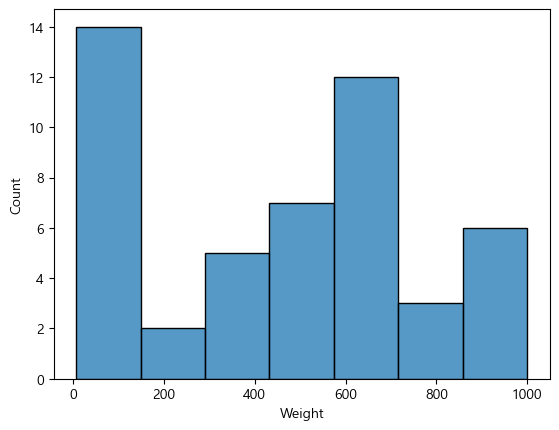

In [49]:
sns.histplot(data=fish_data, x='Weight')
plt.show()

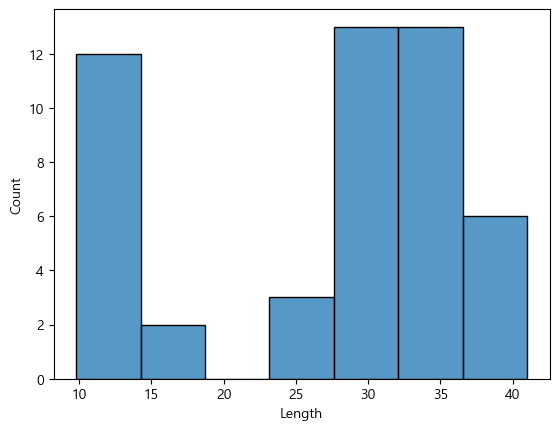

In [51]:
sns.histplot(data=fish_data, x='Length')
plt.show()

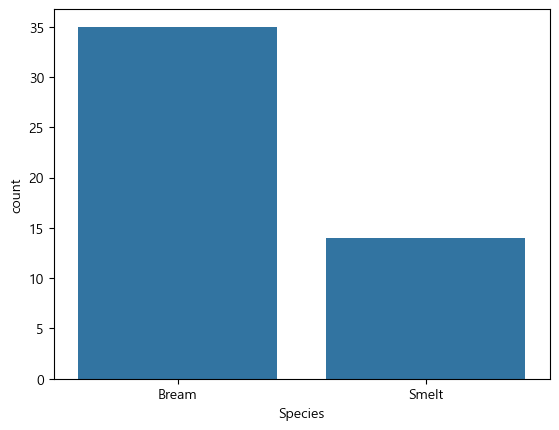

In [53]:
sns.countplot(data=fish_data, x='Species')
plt.show()

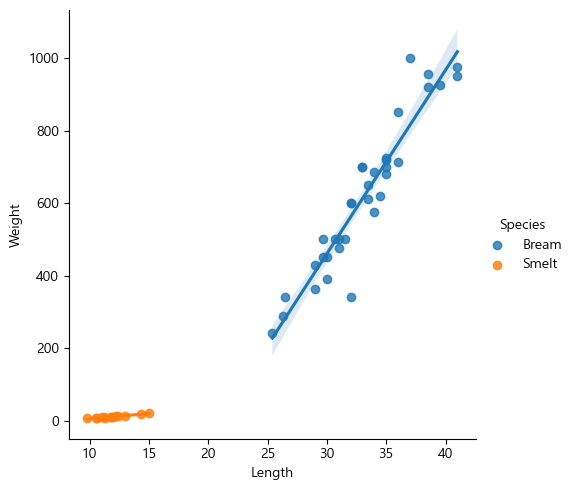

In [57]:
sns.lmplot(data=fish_data, x='Length', y='Weight', hue='Species')

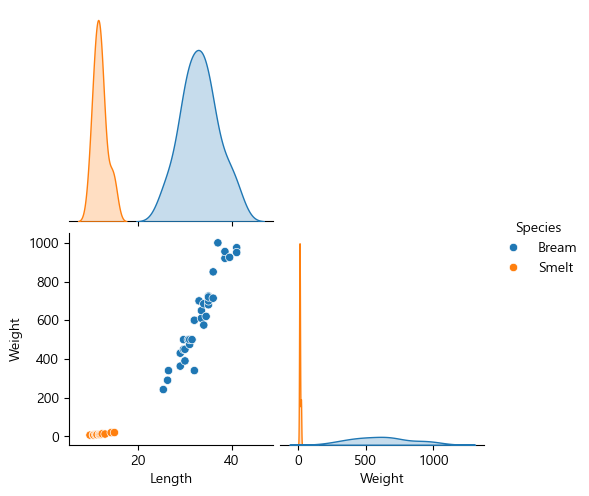

In [66]:
sns.pairplot(data=fish_data, corner=True, hue='Species')

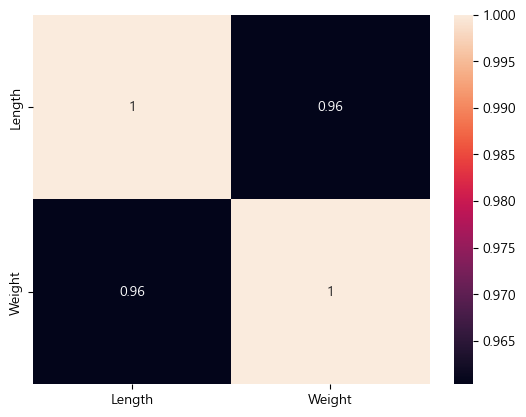

In [70]:
sns.heatmap(fish_data.corr(numeric_only=True), annot=True)
plt.show()

In [75]:
X=fish_data[['Length', 'Weight']]
Y=fish_data['Species']
X.shape, Y.shape, type(X), type(Y)

((49, 2), (49,), pandas.DataFrame, pandas.Series)

In [77]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X, Y)
knn.score(X, Y)

1.0

In [95]:
new_data=pd.DataFrame(data=[[30, 500]], columns=['Length', 'Weight'])
new_data

,Length,Weight
0,30,500


In [97]:
knn.predict(new_data)

array(['Bream'], dtype=object)

In [99]:
KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

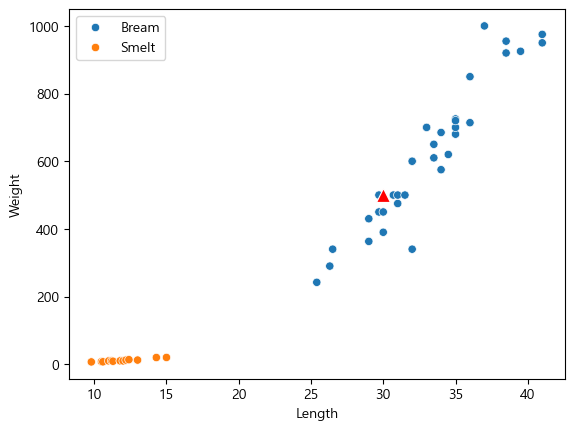

In [101]:
sns.scatterplot(data=fish_data, x='Length', y='Weight', hue='Species')
sns.scatterplot(data=new_data, x='Length', y='Weight', marker='^', color='red', s=100)
plt.show()

In [104]:
d, i=knn.kneighbors(new_data)
print(d)
print(i)

[[ 0.3         0.7         1.          1.5        25.01999201]]
[[ 6  9 11 12 10]]


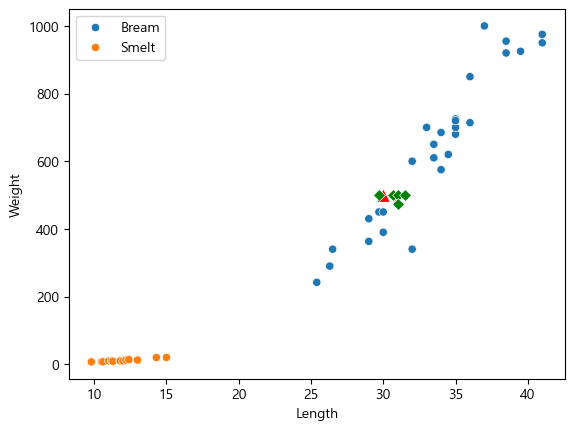

In [111]:
sns.scatterplot(data=fish_data, x='Length', y='Weight', hue='Species')
sns.scatterplot(data=new_data, x='Length', y='Weight', marker='^', color='red', s=100)

for idx in i:
    sns.scatterplot(data=fish_data,
                    x=fish_data.loc[idx, 'Length'], 
                    y=fish_data.loc[idx, 'Weight'], 
                    marker='D', 
                    color='green')

plt.show()

In [113]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1234)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((39, 2), (10, 2), (39,), (10,))

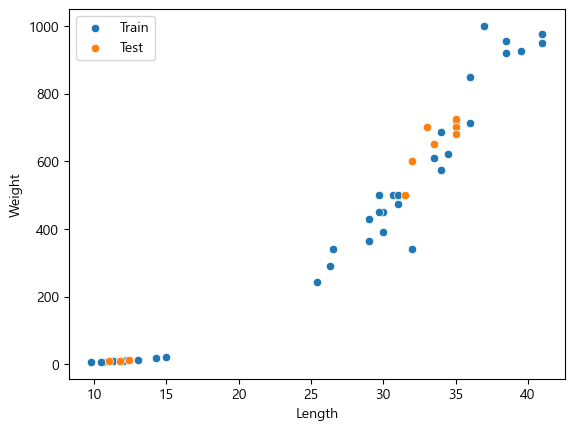

In [115]:
sns.scatterplot(data=X_train, x='Length', y='Weight', label='Train')
sns.scatterplot(data=X_test, x='Length', y='Weight', label='Test')
plt.show()

In [117]:
knn=KNeighborsClassifier()
knn.fit(X_train, Y_train)

knn.score(X_train, Y_train), knn.score(X_test, Y_test)

(1.0, 1.0)

In [119]:
Y_test_pred=knn.predict(X_test)

In [121]:
result=X_test.copy()
result['정답']=Y_test
result['예측']=Y_test_pred
result.head()

,Length,Weight,정답,예측
38,11.0,9.7,Smelt,Smelt
24,35.0,700.0,Bream,Bream
25,35.0,725.0,Bream,Bream
12,31.5,500.0,Bream,Bream
19,33.5,650.0,Bream,Bream


In [123]:
a=pd.DataFrame(data=[[30, 500]], columns=['Length', 'Weight'])
knn.predict(a)

array(['Bream'], dtype=object)

In [127]:
b=pd.DataFrame(data=[[25, 150]], columns=['Length', 'Weight'])
knn.predict(b)

array(['Smelt'], dtype=object)

In [129]:
fish_data.groupby('Species')[['Length', 'Weight']].agg([max, min])

Length        Weight       
           max   min     max    min
Species                            
Bream     41.0  25.4  1000.0  242.0
Smelt     15.0   9.8    19.9    6.7

In [140]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1234)

scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

knn=KNeighborsClassifier()

knn.fit(X_train_scaled, Y_train)

knn.score(X_train_scaled, Y_train)
knn.score(X_test_scaled, Y_test)

1.0

In [145]:
new_df=pd.DataFrame(data=[[25, 150]], columns=['Length', 'Weight'])
new_df_scaled=scaler.transform(new_df)
knn.predict(new_df_scaled)

array(['Bream'], dtype=object)

In [189]:
data=pd.read_csv('./../다운로드/머신러닝/염색공정전체데이터.csv', encoding='cp949')
data.shape

(32608, 18)

In [191]:
data.columns

Index(['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '단위중량(kg)', '투입중량(kg)',
       '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)', '지시온도', '진행온도', '포속1',
       '포속2', '포속3', '포속4', '염색색차 DE'],
      dtype='str')

In [193]:
data['불량여부']=(data['염색색차 DE'] > 3.0).astype(int)

In [197]:
data['불량여부'].value_counts(normalize=True)

불량여부
0    0.848105
1    0.151895
Name: proportion, dtype: float64

In [201]:
dye_5000, _=train_test_split(data, train_size=5000, stratify=data['불량여부'], random_state=1234)
dye_5000.shape

(5000, 19)

In [203]:
dye_5000['불량여부'].value_counts(normalize=True)

불량여부
0    0.8482
1    0.1518
Name: proportion, dtype: float64

In [205]:
new_data=pd.read_csv('./../다운로드/머신러닝/염색공정_5000.csv', encoding='cp949')
new_data.shape

(5000, 19)

In [207]:
new_data.columns

Index(['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '단위중량(kg)', '투입중량(kg)',
       '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)', '지시온도', '진행온도', '포속1',
       '포속2', '포속3', '포속4', '염색색차 DE', '불량여부'],
      dtype='str')

In [209]:
drop_cols=['LOT번호', '검사차수', '작업명', '공정코드', '설비번호', '염색색차 DE']
dye=new_data.drop(columns=drop_cols)

In [211]:
dye.head(2)

,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),지시온도,진행온도,포속1,포속2,포속3,포속4,불량여부
0,324.0,38.8,96.0,0.404167,0.0388,23.41,133.1,133.2,74,73,72,20,0
1,324.0,38.8,96.0,0.404167,0.0388,21.88,126.3,127.1,73,68,146,18,0


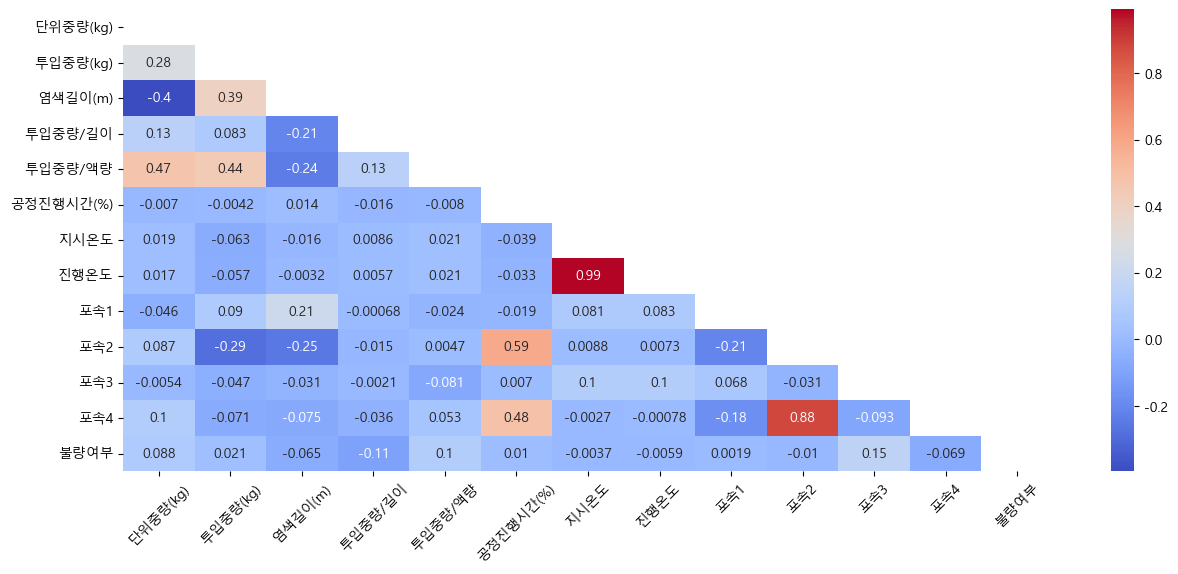

In [226]:
plt.figure(figsize=(15, 6))
sns.heatmap(dye.corr(), 
            annot=True, 
            cmap='coolwarm',
            mask=np.triu(np.ones_like(dye.corr(), dtype=bool)))
plt.xticks(rotation=45)
plt.show()

In [234]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [245]:
col=dye[['진행온도', '지시온도', '포속2', '포속4']]

vif=pd.DataFrame()
vif['변수명']=col.columns
vif['다중 공선상(VIF)']=[variance_inflation_factor(col.values, i) for i in range(4)]
vif

,변수명,다중 공선상(VIF)
0,진행온도,474.691135
1,지시온도,475.615154
2,포속2,8.384958
3,포속4,7.181979


In [247]:
drop_cols=['지시온도', '포속2']
dye=dye.drop(columns=drop_cols)

In [249]:
dye.columns

Index(['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)',
       '진행온도', '포속1', '포속3', '포속4', '불량여부'],
      dtype='str')

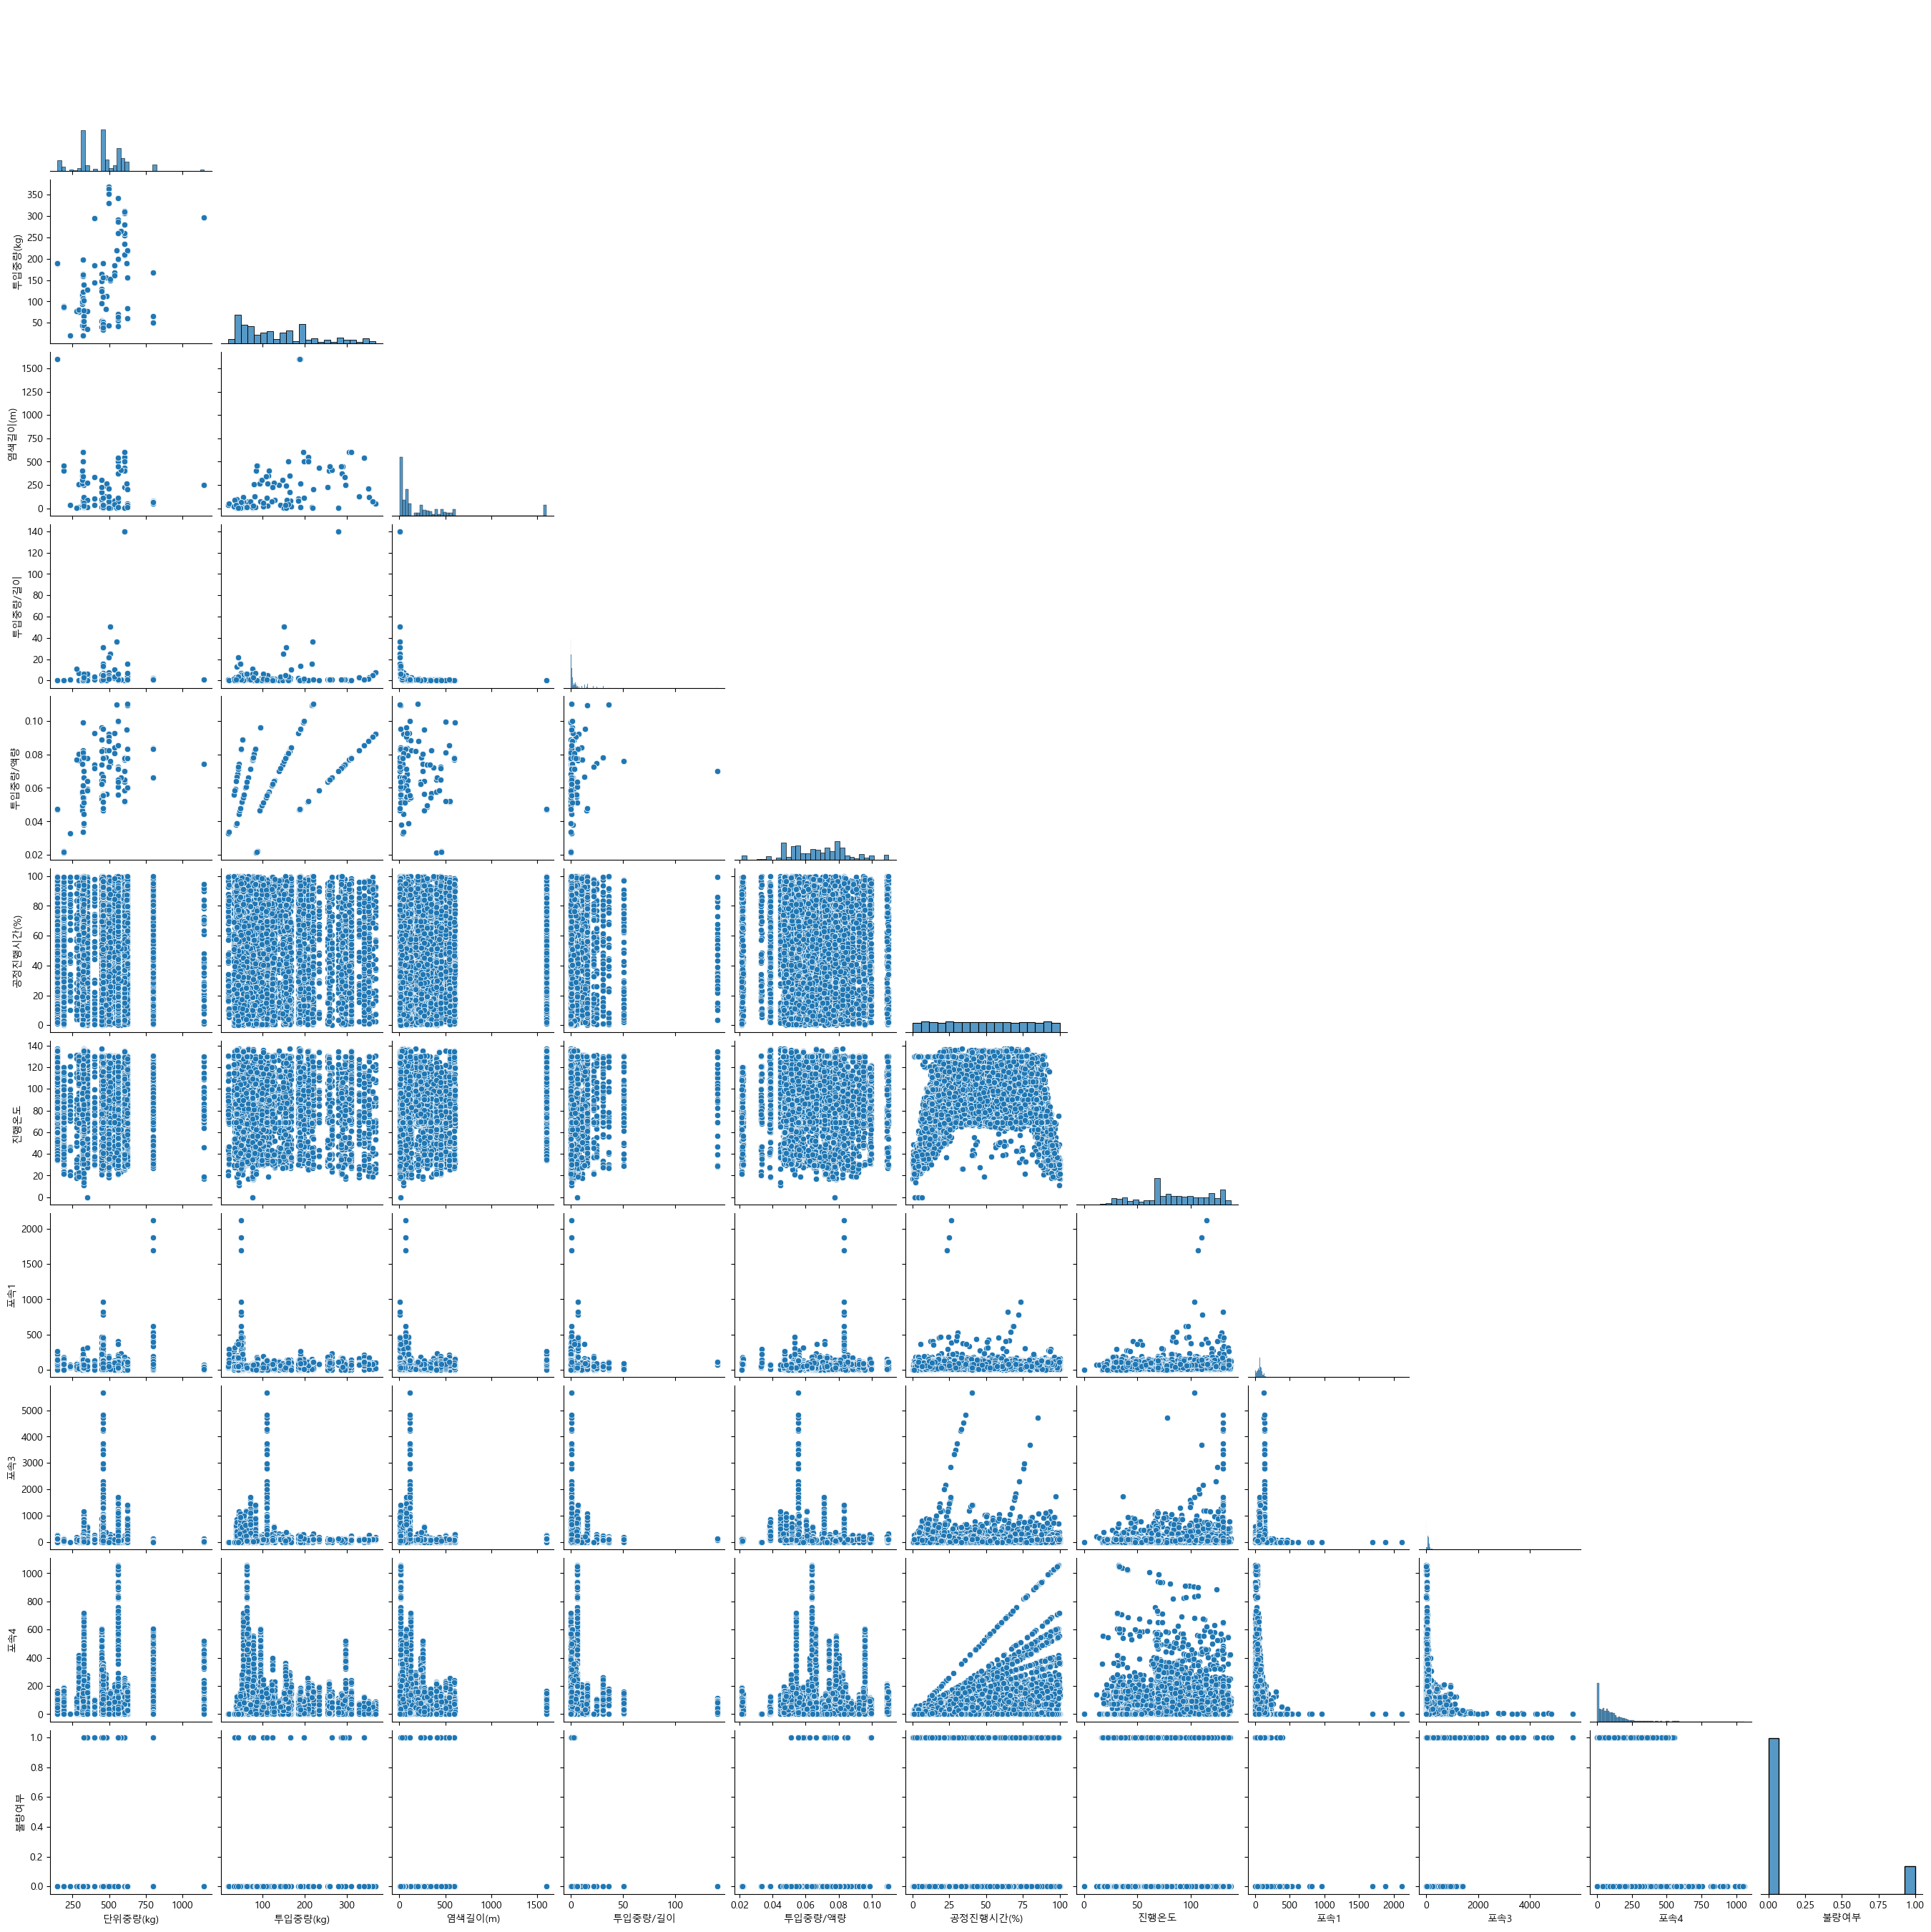

In [251]:
sns.pairplot(data=dye, corner=True)
plt.show()

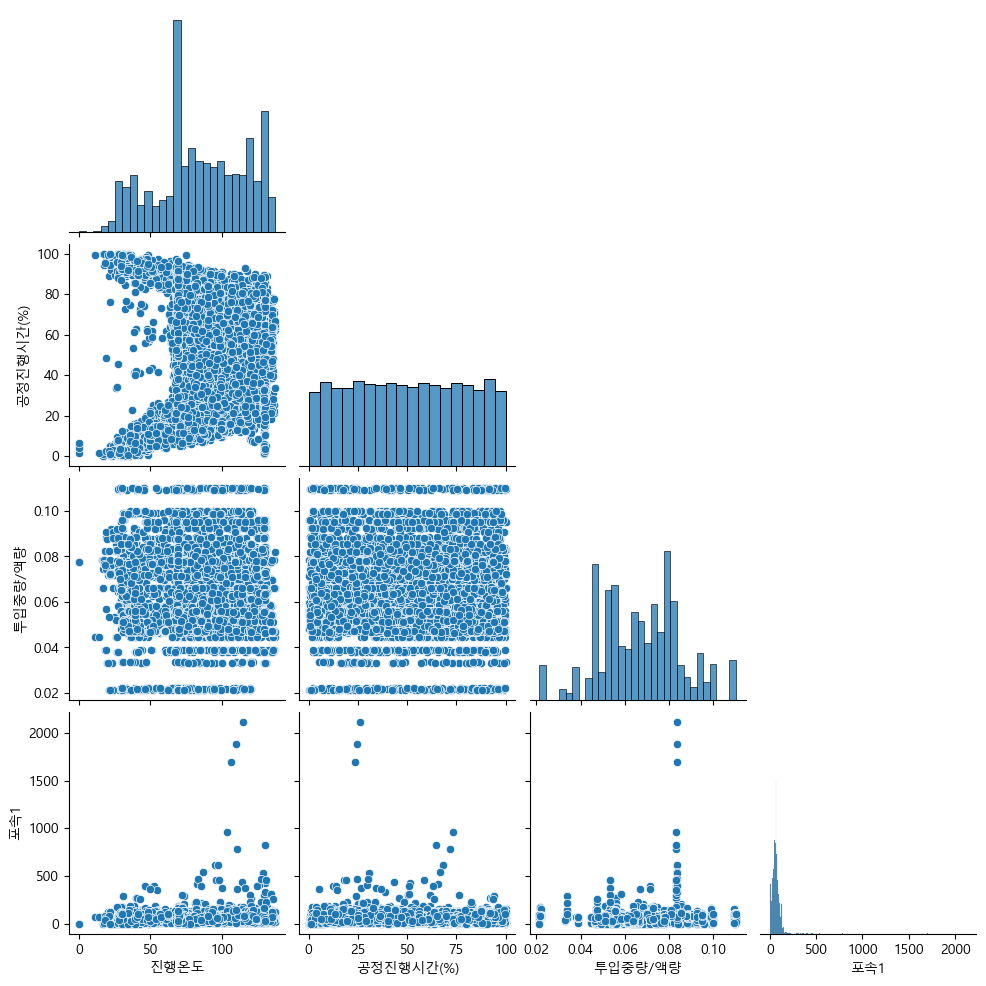

In [255]:
cols=['진행온도', '공정진행시간(%)', '투입중량/액량', '포속1']
sns.pairplot(data=dye[cols], corner=True)
plt.show()

In [259]:
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [261]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, stratify=Y, random_state=1234)

In [263]:
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [265]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, Y_train)
knn.score(X_train_scaled, Y_train), knn.score(X_test_scaled, Y_test)

(0.9696, 0.932)

In [278]:
Y_test_pred=knn.predict(X_test_scaled)

In [280]:
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1060
           1       0.80      0.73      0.77       190

    accuracy                           0.93      1250
   macro avg       0.88      0.85      0.86      1250
weighted avg       0.93      0.93      0.93      1250



In [283]:
# 입력 데이터 : 길이, 퍼치 렝스 
perch_length=np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
                     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
                     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
                     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
                     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
                     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])  

# 정답 데이터 : 무게, 퍼치 웨이트 
perch_weight=np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
                     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
                     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
                     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
                     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
                     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
                     1000.0, 1000.0])                   

perch_length.shape, perch_weight.shape

((56,), (56,))

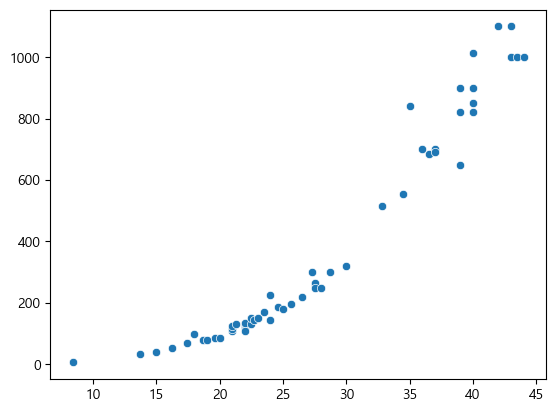

In [285]:
sns.scatterplot(x=perch_length, y=perch_weight)
plt.show()

In [299]:
X_train, X_test, Y_train, Y_test=train_test_split(perch_length, perch_weight, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((42,), (14,), (42,), (14,))

In [301]:
X_train=X_train.reshape(-1, 1)
X_test=X_test.reshape(-1, 1)
X_train.shape, X_test.shape

((42, 1), (14, 1))

In [304]:
knr=KNeighborsRegressor(n_neighbors=3)
knr.fit(X_train, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [306]:
knr.score(X_train, Y_train)

0.9804899950518966

In [308]:
knr.score(X_test, Y_test)

0.9746459963987609

<Axes: >

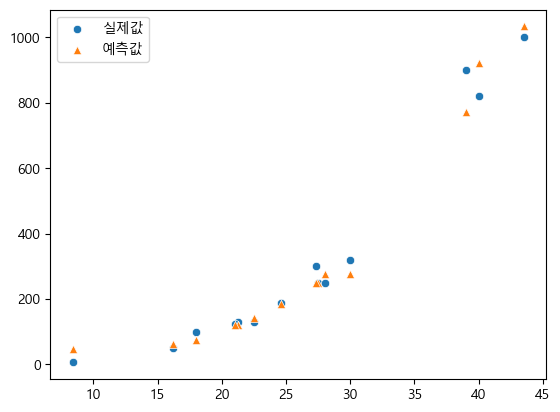

In [310]:
Y_test_pred=knr.predict(X_test)

sns.scatterplot(x=X_test[:, 0], y=Y_test, label='실제값')
sns.scatterplot(x=X_test[:, 0], y=Y_test_pred, marker='^', label='예측값')

In [315]:
result=pd.DataFrame()

result['X_test']=X_test.flatten()

In [317]:
result['Y_test']=Y_test

In [321]:
result['Y_test_pred']=Y_test_pred